<a href="https://colab.research.google.com/github/sakram09/Environmental-Ecology-Ecosystem-Modeling/blob/main/ecology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Environmental Ecology & Ecosystem Modeling

Step 1: Libraries Import Aur Eco-Sensor Data Simulation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Simulate Realistic Environmental Sensor Data (1000 Sites)
print("Simulating ecological sensor telemetry data (1000 environmental sites)...")
np.random.seed(42)
num_sites = 1000

# Generating 6 critical environmental features
water_temp = np.random.normal(loc=18.5, scale=4.0, size=num_sites)       # in Celsius
ph_levels = np.random.normal(loc=7.2, scale=0.6, size=num_sites)         # pH scale
dissolved_oxygen = np.random.normal(loc=6.5, scale=1.8, size=num_sites)  # mg/L
nitrates = np.random.normal(loc=12.0, scale=5.0, size=num_sites)         # mg/L
phosphates = np.random.normal(loc=2.1, scale=0.8, size=num_sites)        # mg/L
turbidity = np.random.normal(loc=15.0, scale=6.0, size=num_sites)        # NTU (water clarity)

# Create DataFrame
feature_names = ['Water_Temperature', 'pH_Level', 'Dissolved_Oxygen', 'Nitrates', 'Phosphates', 'Turbidity']
df_ecology = pd.DataFrame(
    np.column_stack([water_temp, ph_levels, dissolved_oxygen, nitrates, phosphates, turbidity]),
    columns=feature_names
)

# 2. Inject Ecological Rules to Create Target Labels (Biodiversity Health Status)
# Rule: Low oxygen, high nitrates, and extreme temperatures destroy biodiversity
biodiversity_score = (dissolved_oxygen * 2.5) - (nitrates * 0.8) - (phosphates * 1.2) + np.random.normal(0, 2, num_sites)

# Binary Target: 1 = Healthy Ecosystem (High Biodiversity), 0 = Degraded Ecosystem (Low Biodiversity)
y_biodiversity = (biodiversity_score > np.median(biodiversity_score)).astype(int)

print("Ecological Matrix Shape:", df_ecology.shape)
print("Ecosystem Status Generated:", np.bincount(y_biodiversity), "(0: Degraded, 1: Healthy)")

Simulating ecological sensor telemetry data (1000 environmental sites)...
Ecological Matrix Shape: (1000, 6)
Ecosystem Status Generated: [500 500] (0: Degraded, 1: Healthy)


Step 2: Train/Test Split & Feature Normalization

In [2]:
# 3. Split into Train and Test subsets (80/20)
X_train_eco, X_test_eco, y_train_eco, y_test_eco = train_test_split(
    df_ecology, y_biodiversity, test_size=0.20, random_state=42, stratify=y_biodiversity
)

# 4. Normalize sensor features (Z-score Scaling)
scaler_eco = StandardScaler()
X_train_scaled = scaler_eco.fit_transform(X_train_eco)
X_test_scaled = scaler_eco.transform(X_test_eco)

print("Data successfully split and normalized for training.")

Data successfully split and normalized for training.


Step 3: Random Forest Training Aur Robust Cross-Validation

In [3]:
# 5. Initialize Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)

# 6. Run 5-Fold Cross-Validation to evaluate framework stability
print("Running 5-Fold Cross-Validation on Ecological Data...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train_eco, cv=kf, scoring='accuracy')

print(f"Cross-Validation Accuracies: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean() * 100:.2%}")

# Train the final model on entire training subset
rf_model.fit(X_train_scaled, y_train_eco)

Running 5-Fold Cross-Validation on Ecological Data...
Cross-Validation Accuracies: [0.86875 0.875   0.8875  0.875   0.85625]
Mean CV Accuracy: 8725.00%


RandomForestClassifier(max_depth=8, random_state=42)

Step 4: Test Set Predictions & Confusion Matrix Visualization


=== Test Metrics Report ===
                    precision    recall  f1-score   support

Degraded Ecosystem       0.87      0.91      0.89       100
 Healthy Ecosystem       0.91      0.86      0.88       100

          accuracy                           0.89       200
         macro avg       0.89      0.89      0.88       200
      weighted avg       0.89      0.89      0.88       200



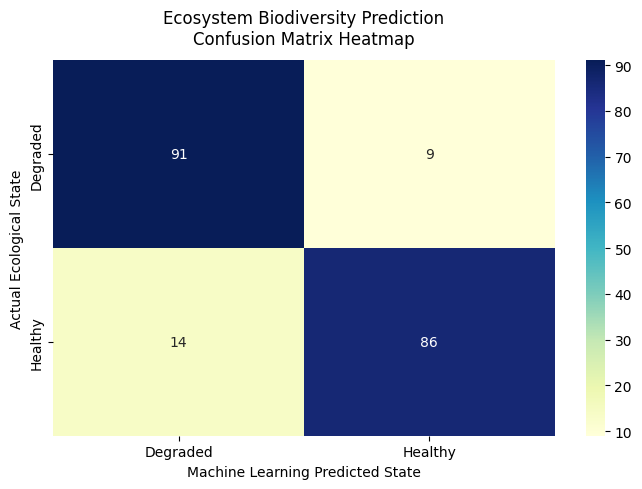

In [4]:
# 7. Evaluate performance on 200 untouched validation sites
y_pred_eco = rf_model.predict(X_test_scaled)
print("\n=== Test Metrics Report ===")
print(classification_report(y_test_eco, y_pred_eco, target_names=['Degraded Ecosystem', 'Healthy Ecosystem']))

# 8. Plot the Confusion Matrix Heatmap
cm_eco = confusion_matrix(y_test_eco, y_pred_eco)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_eco, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Degraded', 'Healthy'], yticklabels=['Degraded', 'Healthy'])
plt.title('Ecosystem Biodiversity Prediction\nConfusion Matrix Heatmap', fontsize=12, pad=12)
plt.ylabel('Actual Ecological State')
plt.xlabel('Machine Learning Predicted State')
plt.tight_layout()
plt.show()

Step 5: THE PROFESSOR MAGNET: Feature Importance Plotting!

/tmp/ipykernel_6256/2999448864.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='viridis')


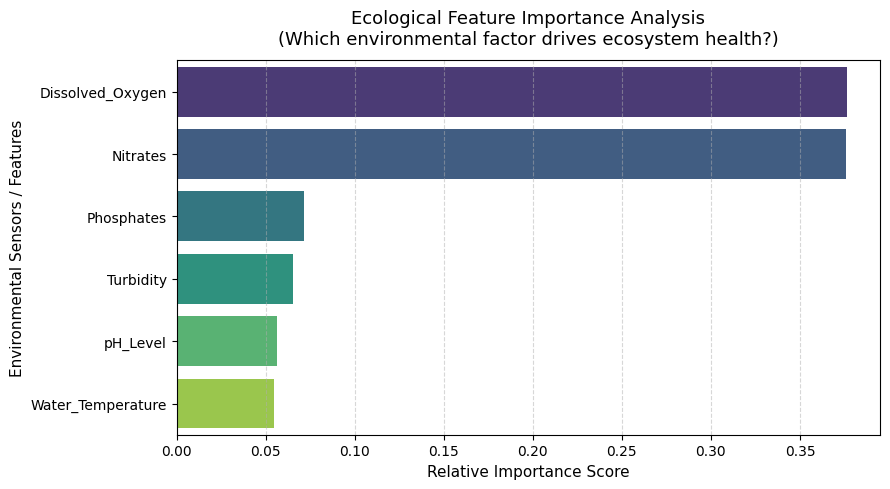

In [5]:
# 9. Extract and Plot Feature Importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Create plot layout
plt.figure(figsize=(9, 5))
sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='viridis')
plt.title('Ecological Feature Importance Analysis\n(Which environmental factor drives ecosystem health?)', fontsize=13, pad=12)
plt.xlabel('Relative Importance Score', fontsize=11)
plt.ylabel('Environmental Sensors / Features', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
Step 6: Pipeline Extraction & Serialization (joblib)

In [6]:
import joblib

# 10. Serialize the ecology model components
joblib.dump(rf_model, 'ecosystem_rf_model.pkl')
joblib.dump(scaler_eco, 'ecology_scaler.pkl')

print("Success! 'ecosystem_rf_model.pkl' aur 'ecology_scaler.pkl' save ho chuke hain.")

Success! 'ecosystem_rf_model.pkl' aur 'ecology_scaler.pkl' save ho chuke hain.
